# 🧪LAB: Partial Least Squares Regression

In this lab, you will explore **Partial Least Squares (PLS) Regression**, a powerful technique for modeling relationships between high-dimensional, collinear predictors and a continuous outcome. You will begin with a **group discussion** after reading about the method. Next, you will become familiar with its implementation in `scikit-learn` by **recreating and reflecting on one of their tutorials**. Finally, you will apply PLS to a **real-world chemoinformatics dataset** that includes binary molecular fingerprints as predictors and a continuous permeability outcome for a set of chemical compounds.

PLS is particularly useful when the number of predictors is large and highly correlated, making traditional regression methods unstable or ineffective. You will also compare PLS with an alternative predictive model that also involves a dimensionality-reduction approach: **Penalized Principal Component Regression (PCR)**.

---

**Collaboration Note**: This assignment is designed to support collaborative work. We encourage you to divide tasks among group members so that everyone can contribute meaningfully. Many components of the assignment can be approached in parallel or split logically across team members. Good coordination and thoughtful integration of your work will lead to a stronger final result.

--- 

In total, this lab assignment will be worth **100 points**.

## 1. Reading & Group Discussion (10 Points)

Carefully read **Sections 6.2 and 6.3** of the *An Introduction to Statistical Learning* book (Reference B). The first section introduces Principal Component Regression (PCR), which we already covered in a previous class. The second section, instead, introduces Partial Least Squares (PLS).

After reviewing the content, discuss with your group and then answer the following questions:

a. What is the key difference between Principal Component Regression (PCR) and Partial Least Squares (PLS)

b. Why might PCR fail to find directions that are useful for predicting the response `Y`? 

c. In PLS, how is the first direction `Z₁` computed? 

d. What are some similarities and differences between PLS and penalized regression? 

a. The key difference is how each method chooses its directions/components for dimensionality reduction:

PCR is unsupervised when it comes to constructing the components. It finds the principal components of the predictor matrix X based on the directions that explain the most variance in X, and the response variable Y plays no role at all in finding these directions. PCR uses Y only after the components are constructed, in the regression step. This means PCR has no guarantee that the directions which best explain variance in X are actually the directions most related to Y.

PLS, by contrast, is supervised. When constructing its components or PLS directions, it uses both X and Y. Specifically, after standardizing the predictors, PLS computes each direction by looking at how strongly each predictor is associated with the response via linear regression of Y onto each predictor, then combining predictors weighted by those associations. This means PLS actively seeks out directions that explain variance in X and also correlated with Y, rather than directions that only maximize variance in X.

b. The issue is how the directions get picked. PCR chooses its components in an unsupervised way; it only looks at X and picks whichever directions capture the most variance, without checking if those directions relate to Y. This is fine if high-variance directions in X just happen to also be predictive of Y, but there's no guarantee. A predictor could vary a lot just from noise or irrelevant structure, and a lower-variance direction might actually be the one that matters for predicting Y. If PCR latches onto the wrong direction, its predictions could fail.

c. After standardizing the predictors, PLS sets each weight to the coefficient from regressing Y on $X_j$ alone (simple linear regression). So predictors more strongly correlated with Y get larger weights. The first direction is:

$Z_1 = \sum_j \varphi_{j1} X_j$

d. 

Similarities:

- Both address issues with many/correlated predictors by reducing model flexibility.
- Both trade some bias for a reduction in variance.
- Both need a tuning parameter chosen by cross validation (M for PLS, $\lambda$ for ridge/lasso). 

Differences:

- PLS reduces dimensionality by building new components, ridge/lasso keep the original predictors and just shrink their coefficients.
- Lasso can zero out coefficients entirely with variable selection, but all predictors still contribute in PLS and ridge.
- PLS uses Y to construct its components, ridge/lasso don't use Y, they just penalize coefficient magnitude.

## 2. Recreate, Explain, Experiment & Reflect (35 points)

Follow this tutorial on Partial Least Squares (PLS) from the official scikit-learn documentation:

📘 [scikit-learn: PLS regression example](https://scikit-learn.org/stable/auto_examples/cross_decomposition/plot_pcr_vs_pls.html)

Your goal is to **recreate the PLS portion of the tutorial in this notebook**, and make sure you understand what each part of the code is doing. This will give you the opportunity to build intuition for how PLS works. Be thorough in your answers and interpretations — this will help you when working with real data later in this lab assignment.

### a. Recreate
- Load the dataset used in the tutorial. Make sure to create a training/reporting partition.
- Fit a `PLSRegression` model with 1 component. 

In [35]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_squared_error

rng = np.random.RandomState(0)
n_samples = 500
cov = [[3, 3], [3, 4]]

X = rng.multivariate_normal(mean=[0, 0], cov=cov, size=n_samples)
pca = PCA(n_components=2).fit(X)
y = X.dot(pca.components_[1]) + rng.normal(size=n_samples) / 2

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=rng)

pls = PLSRegression(n_components=1)
pls.fit(X_train, y_train)


,"n_components n_components: int, default=2Number of components to keep. Should be in `[1, n_features]`.",1
,"scale scale: bool, default=TrueWhether to scale `X` and `y`.",True
,"max_iter max_iter: int, default=500The maximum number of iterations of the power method when`algorithm='nipals'`. Ignored otherwise.",500
,"tol tol: float, default=1e-06The tolerance used as convergence criteria in the power method: thealgorithm stops whenever the squared norm of `u_i - u_{i-1}` is lessthan `tol`, where `u` corresponds to the left singular vector.",1e-06
,"copy copy: bool, default=TrueWhether to copy `X` and `y` in :term:`fit` before applying centering,and potentially scaling. If `False`, these operations will be doneinplace, modifying both arrays.",True


In [36]:
print(f"PLS r-squared {pls.score(X_test, y_test):.3f}")
print(f"PLS MSE {mean_squared_error(y_test, pls.predict(X_test)):.3f}")

PLS r-squared 0.658
PLS MSE 0.226


### b. Explain
For **every block of code**, add a markdown cell that explains:

- What is the goal of this step?
- Why is this important in a PLS regression pipeline?
- What does the output mean or tell us?

The above block of code has multiple goals:
- First, we import the following packages needed to do the PLS Regression. This is crucial because we cannot perform the PLS regression pipeline without the necessary packages. There is no output yet at this point.
  - numpy for data generation
  - sklearn.decomposition for the PCA used to generate the y data
  - sklearn.model_selection to create the training/reporting partition
  - sklearn.cross_decomposition for the PLS regression itself
  - sklearn.metrics to calculate MSE
- Next, we load in the dataset by creating a random sample with random state 0 and 500 samples. We create the X data using a multivariate normal distribution with the given covariance matrix, mean, random state, and sample size. This is important because it will be the data used for the PLS regression pipeline. There is no output yet at this point. 
- Then, we create our train/test split. This is critical for the PLS regression pipeline because it allows us to train our model on one subset of the data and test it with another to avoid data leakage and to ensure the data tested has not been seen by the model. There is no output yet at this point, but we have now generated a training and a testing set for our data.
- Finally, we fit the PLS regression with 1 component to our training data and print the R² and MSE. This is important because we have now fit the model to our data, allowing us to make predictions in the future. The output is a box with the label PLSRegression that details the parameters used in fitting the model. The output is also an R² of 0.658 and an MSE of 0.226. This means about 65.8% of the variation in y is explained by the model. The MSE is also somewhat low, meaning our error is pretty low.

### c. Experiment
Make the following changes:
- Change the number of components to **2 components** and fit again the model.
- Plot the **predicted vs. actual** response values on the reporting set.
- Report **R²** and **Mean Squared Error (MSE)** for your model
- On the reporting set, create scatter plots showing each component on X against y. (Hint: Use the `transform` method applied to X to get each component). In the title, show the correlation coefficient between both variables. Your first component should correlate more (in magnitude) with the outcome.

In [37]:
pls = PLSRegression(n_components=2)
pls.fit(X_train, y_train)

,"n_components n_components: int, default=2Number of components to keep. Should be in `[1, n_features]`.",2
,"scale scale: bool, default=TrueWhether to scale `X` and `y`.",True
,"max_iter max_iter: int, default=500The maximum number of iterations of the power method when`algorithm='nipals'`. Ignored otherwise.",500
,"tol tol: float, default=1e-06The tolerance used as convergence criteria in the power method: thealgorithm stops whenever the squared norm of `u_i - u_{i-1}` is lessthan `tol`, where `u` corresponds to the left singular vector.",1e-06
,"copy copy: bool, default=TrueWhether to copy `X` and `y` in :term:`fit` before applying centering,and potentially scaling. If `False`, these operations will be doneinplace, modifying both arrays.",True


This code block is intended to change the number of components of the regression to 2 components and then fit the PLS model one more time. It is important for the pipeline because we are changing the number of components in the pipeline, and we are fitting the model. The output is a box with the label PLSRegression that details the parameters used in fitting the model. 

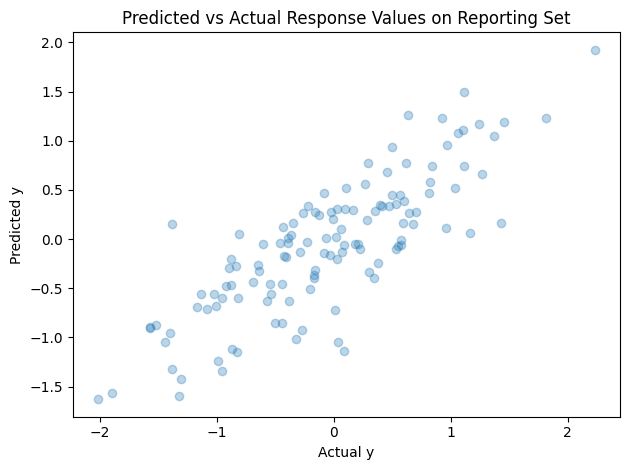

In [38]:
import matplotlib.pyplot as plt

plt.scatter(y_test, pls.predict(X_test), alpha=0.3)
plt.xlabel("Actual y")
plt.ylabel("Predicted y")
plt.title("Predicted vs Actual Response Values on Reporting Set")
plt.tight_layout()
plt.show()

The above code block plots the **predicted vs. actual** response values on the reporting set. We use matplotlib to form a scatterplot of actual vs predicted responses and title the axes and plot. This step is important because it allows us to visualize our predictions and our actual y_test set. This output tells us how close our predictions were to the actual test set. It appears they were quite close, with a few outliers. 

In [39]:
print(f"PLS r-squared {pls.score(X_test, y_test):.3f}")
print(f"PLS MSE {mean_squared_error(y_test, pls.predict(X_test)):.3f}")

PLS r-squared 0.673
PLS MSE 0.217


The above code block reports the **R²** and **Mean Squared Error (MSE)** for our model. This step is intended to help us understand how accurate our model is, and how often it is correct. This is crucial in the PLS regression pipeline because we must determine if we have a good model before continuing to use it in the pipeline. If our accuracy is very low, it tells us the model may not be a good choice. The PLS model achieved an **R²** of 0.673, meaning it explains approximately 67.3% of the variability in the response variable. Its MSE of 0.217 indicates relatively small prediction errors, although these metrics should be compared with other models to determine whether PLS provides the best predictive performance.

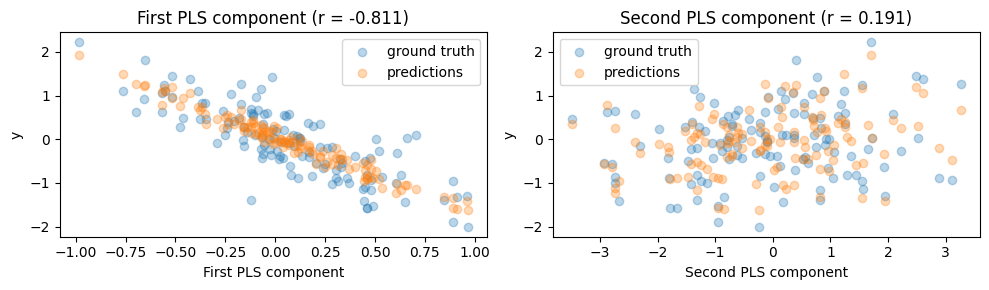

In [40]:
import matplotlib.pyplot as plt

X_components = pls.transform(X_test)
r1 = np.corrcoef(X_components[:, 0], np.asarray(y_test).ravel())[0, 1]
r2 = np.corrcoef(X_components[:, 1], np.asarray(y_test).ravel())[0, 1]

fig, axes = plt.subplots(1, 2, figsize=(10, 3))

axes[0].scatter(X_components[:, 0], y_test, alpha=0.3, label="ground truth")
axes[0].scatter(X_components[:, 0], pls.predict(X_test).ravel(), alpha=0.3, label="predictions")
axes[0].set(
    xlabel="First PLS component",
    ylabel="y",
    title=f"First PLS component (r = {r1:.3f})",
)
axes[0].legend()

axes[1].scatter(X_components[:, 1], y_test, alpha=0.3, label="ground truth")
axes[1].scatter(X_components[:, 1], pls.predict(X_test).ravel(), alpha=0.3, label="predictions")
axes[1].set(
    xlabel="Second PLS component",
    ylabel="y",
    title=f"Second PLS component (r = {r2:.3f})",
)
axes[1].legend()

plt.tight_layout()
plt.show()



This final code block creates scatter plots showing each component on X against y. The plots' titles show the correlation coefficient between both variables. The goal of this step is to examine the PLS components and see how strongly each one relates to the target variable y. This is important in the PLS regression pipeline because looking at these components helps us understand which components are actually carrying predictive information. The output from the first component tells us that with a correlation coefficient of -0.811, there is a strong negative relationship.  This means the first component contains a lot of useful predictive information. The second PLS component has a much weaker correlation coefficient of 0.191. So, this component contributes much less predictive information on its own. This visualization tells us that most of the useful signal is concentrated in the first component, while the second component adds comparatively little information about y.

### d. Reflect
Finally, answer these questions:

- What do the learned PLS components represent in your dataset?
  - The PLS components are new features created as combinations of the original features. They are designed to summarize the predictors in ways that are most useful for predicting y. In our results, the first component contains much more predictive information because it has a strong correlation with y (r=-0.811), while the second component has a much weaker relationship (r=0.191).
- Did increasing the number of components improve performance?
  - Increasing the number of components only slightly improved performance. When we increased from 1 to 2 components, MSE dropped from 0.226 to 0.217, a small but noticeable improvement in error. The R² increased from 0.658 to 0.673, which is also a good indicator of improved performance. These are small changes, but they do show improvement as the number of components is increased. 
- What makes PLS different from PCA?
  - The key difference is that PLS considers the target y when creating components, while PCA does not. PCA finds components that explain the greatest amount of variation in X, regardless of whether that variation helps predict y. PLS finds components that capture variation in X that is related to y. This makes PLS a supervised method, whereas PCA is unsupervised.

## 3. PLS on real data: Molecular Fingerprints and Permeability (50 points)

In this final part of the lab, you will apply PLS Regression to a real-world, high-dimensional dataset from pharmaceutical research.

The goal is to build a predictive model of compound permeability—a key property that determines a molecule’s ability to cross biological membranes such as the intestinal wall or the blood–brain barrier. Permeability is critical in drug development, as compounds that cannot reach their target tissues may ultimately fail despite promising initial results.

You will work with a dataset containing 165 compounds characterized by 1,107 binary molecular fingerprints, which indicate the presence or absence of specific chemical substructures. Your task is to use PLS to predict each compound's permeability and evaluate whether such a model could serve as a computational alternative to expensive, labor-intensive lab assays.

Here the link to the dataset: https://github.com/UVADS/DS-4021/blob/84e85842222820f6d60bfdfd051c6d1556d98479/datasets/lab01_data.csv

### a. Prepare data

- Load the dataset.
- Separate the molecular fingerprint variables (`X`) from the permeability values (`y`).
- Split the data into training and reporting sets (e.g., 70/30 split).

### b. Create a pipeline.

Create a pipeline that includes the following: 

- A variance thresholding step to remove near-constant binary features, since molecular fingerprints are typically sparse.
(Hint: you may want to check the `feature_selection` module in `scikit-learn`.)
- A standardization step.
- The Partial Least Squares Regression method.

### c. Optimize and train.

After you create the pipeline, you should optimize (using cross-validation) and train your pipeline. Your optimization should tune the number of PLS components. After training, report:

- The number of predictors remaining after the variance thresholding step
- The selected number of PLS components
- The cross-validated **R²** on the training set.


### d. Evaluate

- Use the best PLS model to predict permeability on the reporting set
- Report the reporting set R²

### e. Compare.

- Compare with the performance obtained using a penalized principal component regression. You may experiment with Lasso, Ridge or/and ElasticNet. Make sure to encapsulate this model into a pipeline and optimize it as well.


### f. Reflect

Discuss:
- Which model performed best?
- Would you trust any of your models enough to replace the permeability lab assay?
- What would be the trade-offs of doing so?

In [41]:
#Part A
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
url = "https://raw.githubusercontent.com/UVADS/DS-4021/84e85842222820f6d60bfdfd051c6d1556d98479/datasets/lab01_data.csv"
data = pd.read_csv(url)
data.head()

,fingerprint1,fingerprint2,fingerprint3,fingerprint4,fingerprint5,fingerprint6,fingerprint7,fingerprint8,fingerprint9,fingerprint10,...,fingerprint1099,fingerprint1100,fingerprint1101,fingerprint1102,fingerprint1103,fingerprint1104,fingerprint1105,fingerprint1106,fingerprint1107,permeability
0,0,0,0,0,0,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,12.520
1,0,0,0,0,0,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,1.120
2,0,0,0,0,0,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,19.405
3,0,0,0,0,0,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,1.730
4,0,0,0,0,0,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,1.680


In [42]:
X = data.drop(columns=["permeability"])
y = data["permeability"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

#Part B
pls_pipeline = Pipeline(steps=[
    ("variance_threshold", VarianceThreshold()),
    ("scaler", StandardScaler()),
    ("pls", PLSRegression())
])
pls_pipeline.fit(X_train, y_train)

print(f"Number of predictors remaining after variance thresholding: {pls_pipeline.named_steps['variance_threshold'].get_support().sum()}")
print(f"Selected number of PLS components: {pls_pipeline.named_steps['pls'].n_components}")
print(f"Cross-validated R² on training set: {pls_pipeline.score(X_train, y_train)}")

Number of predictors remaining after variance thresholding: 882
Selected number of PLS components: 2
Cross-validated R² on training set: 0.6485407112493979


In [43]:
#Part C
param_grid = {
    "pls__n_components": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "variance_threshold__threshold": [0.0, 0.05, 0.1, 0.2]
}

cv = GridSearchCV(pls_pipeline, param_grid=param_grid, cv=5, scoring='r2')
cv.fit(X_train, y_train)

best_pls_pipeline = cv.best_estimator_
print(f"Best parameters found: {cv.best_params_}")
print(f"Number of predictors remaining after variance thresholding: {best_pls_pipeline.named_steps['variance_threshold'].get_support().sum()}")
print(f"Selected number of PLS components: {best_pls_pipeline.named_steps['pls'].n_components}")
print(f"Cross-validated R² on training set (best score): {cv.best_score_}")

Best parameters found: {'pls__n_components': 5, 'variance_threshold__threshold': 0.2}
Number of predictors remaining after variance thresholding: 110
Selected number of PLS components: 5
Cross-validated R² on training set (best score): 0.4246986776878042


In [44]:
#Part D
best_pls_pipeline.fit(X_train, y_train)
y_pred = best_pls_pipeline.predict(X_test)
r2 = best_pls_pipeline.score(X_test, y_test)
print(f"R² on reporting set: {r2}")

R² on reporting set: 0.42169803567044806


In [45]:
#Part E
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression

penalized_principal_component_regression = Pipeline(steps = [
    ("variance_threshold", VarianceThreshold()),
    ("scaler", StandardScaler()),
    ("pca", PCA()),
    ("regression", Ridge())
])

param_grid_pcr = {
    "variance_threshold__threshold": [0.0, 0.05, 0.1, 0.2],
    "pca__n_components": [5, 10, 15, 20, 30, 50],
    "regression__alpha": [0.1, 1.0, 10.0, 100.0, 1000.0],
    "regression" : [Ridge(), Lasso(), ElasticNet()]
}

cv_pcr = GridSearchCV(penalized_principal_component_regression, param_grid=param_grid_pcr, cv=5, scoring='r2')
cv_pcr.fit(X_train, y_train)

best_pcr_pipeline = cv_pcr.best_estimator_
print(f"Best parameters found: {cv_pcr.best_params_}")
print(f"Cross-validated R² on training set (best score): {cv_pcr.best_score_}")
print(f"R² on reporting set: {best_pcr_pipeline.score(X_test, y_test)}")

Best parameters found: {'pca__n_components': 50, 'regression': Ridge(), 'regression__alpha': 10.0, 'variance_threshold__threshold': 0.2}
Cross-validated R² on training set (best score): 0.44110168123954036
R² on reporting set: 0.3052031234940812


Part F: Discuss:
- Which model performed best?
  - The best-performing model was Partial Least Squares with 5 components and a variance threshold of 0.2, based on its reporting-set R².
- Would you trust any of your models enough to replace the permeability lab assay? 
  - No. None of the models achieved a reporting-set R² above 0.5, meaning they explained less than half of the variation in permeability on that set. The remaining prediction error is concerning. These models could help screen compounds, but replacing the assay would require further validation and evidence that their errors are acceptable for the intended use. 
- What would be the trade-offs of doing so?
  - Model predictions could reduce testing time, costs, and laboratory labor, allowing more compounds to be screened quickly. However, inaccurate predictions could lead us to reject promising compounds or pursue unsuitable ones. Using the model for initial screening and confirming results with laboratory assays could balance efficiency and reliability.

## 4. Collaboration Reflection (5 points)

As a group, identify **one specific challenge or inefficiency** you encountered while working on this lab. In 3–5 sentences:

1. Briefly describe what happened and how it affected your work.
2. Identify one concrete action your group will take to avoid or better manage this issue in the next lab.

If your group encountered no major problem, identify one aspect of your collaboration that could still be improved.

One challenge our group faced was communication; we collaborated very well together, but at times we struggled to communicate who was responsible for each aspect of the lab and by what date. We communicated via a text group chat, which made it harder to ensure everyone was on the same page regarding deadlines and responsibilities as we were not together in-person. 
In the future, setting deadlines and having more concrete divisions of work from the beginning would improve our efficiency as a group moving forward into Lab 2. For Lab 2, before we start the project, we will divide the sections among the three of us in person. We will also set deadlines while together in class in order to stay on top of the work and finish well before the due date.